# TheXIBook — Starting XI Recommendation: Research Walkthrough

This notebook mirrors Section 3.6 of the thesis (*Player-Level Modelling and Starting XI Recommendation*), executing the same code that ships in the production UmbraRo backend and loading the same persisted result files that produced Tables 3.7--3.10 in the chapter.

It is intended as the **single reading entry point** for the player-level research --- the analogue of `TheNotebook.ipynb` for the team-level predictive + prescriptive pipeline. The XI codebase itself remains the canonical source of truth; this notebook imports from it rather than duplicating its logic.

## Structure

1. **Data Source** (§3.6.1) — what is loaded and where it comes from.
2. **Feature Engineering** (§3.6.2) — per-90 normalisation, empirical-Bayes shrinkage, time decay, availability features, squad detection, opponent profile, fine positional taxonomy, position-aware composite, tanh squash, Sportradar cross-check.
3. **Selection Rule** (§3.6.3) — Hungarian assignment on a worked example.
4. **Supervised Lineup Classifier** (§3.6.4) — feature vector and Logistic-Regression head.
5. **Validation** (§3.6.5) — per-team Jaccard@11 and U Cluj methodological progression, reproducing Tables 3.8 and 3.9.
6. **Availability-Feature Ablation** (§3.6.6) — Arm A vs B vs C, reproducing Table 3.10 and the $+10.32$ pp leakage delta.
7. **Limitations & Future Work** (§3.6.7) — pointers to the chapter's explicit caveats.
8. **File Index** — every source file (`.py`, `.json`, `.csv`) used by this notebook, so a reader who wants to dig deeper knows exactly where to look.


In [1]:
# ── 0. Setup ──────────────────────────────────────────────────────────────
import json
import os
import sys
from pathlib import Path
from typing import Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Resolve paths relative to the notebook's location (data/).
HERE = Path(os.getcwd()).resolve()
REPO_ROOT = HERE.parent if HERE.name == 'data' else HERE
BACKEND = REPO_ROOT / 'backend'
ML_DATA = BACKEND / 'ml' / 'data'
FIG_DIR = REPO_ROOT / 'figures'
SCRIPTS = BACKEND / 'scripts'

# Make the production code importable.
for p in (str(REPO_ROOT), str(BACKEND)):
    if p not in sys.path:
        sys.path.insert(0, p)

print(f'Notebook root: {REPO_ROOT}')
print(f'Backend code:  {BACKEND}')
print(f'ML data:       {ML_DATA}')
print(f'Figures:       {FIG_DIR}')


Notebook root: C:\Users\Mihai\OneDrive\Desktop\Facultate\Thesis\UHack\.claude\worktrees\strange-gauss-4b272c
Backend code:  C:\Users\Mihai\OneDrive\Desktop\Facultate\Thesis\UHack\.claude\worktrees\strange-gauss-4b272c\backend
ML data:       C:\Users\Mihai\OneDrive\Desktop\Facultate\Thesis\UHack\.claude\worktrees\strange-gauss-4b272c\backend\ml\data
Figures:       C:\Users\Mihai\OneDrive\Desktop\Facultate\Thesis\UHack\.claude\worktrees\strange-gauss-4b272c\figures


## 1. Data Source (mirrors §3.6.1)

Two upstream feeds power the XI predictor:

- **Wyscout per-match player statistics** — one JSON per Romanian Superliga fixture in `backend/ml/data/drive_cache/`. Each file records ~20 action-level KPIs per player (minutes, passes, duels, shots, goals, assists, expected-goal contributions, defensive actions, …) plus the positional label and `matchesInStart` flag the supervised label depends on.
- **Sportradar competitor-profile feed** — `sportradar_positions_league.json` supplies current squad rosters for all sixteen clubs and the league-wide team registry that the predictor uses to map a club's Wyscout identifier to its Sportradar competitor identifier.

The cells below count these inputs to reproduce the numbers stated in §3.6.1 of the thesis.


In [2]:
# 1a. Wyscout per-match JSON files
drive_cache = ML_DATA / 'drive_cache'
wy_files = sorted([f for f in os.listdir(drive_cache) if f.endswith('.json')])
print(f'Wyscout per-match JSON files: {len(wy_files)}')
print(f'Sample filename: {wy_files[0]}')


Wyscout per-match JSON files: 279
Sample filename: Argeș - Botoşani, 0-0_players_stats.json


In [3]:
# 1b. League-wide lineup history (pooled across 16 clubs)
with open(ML_DATA / 'lineup_history_league.json', encoding='utf-8') as f:
    lhl = json.load(f)
tot_fixtures = sum(t['n_fixtures'] for t in lhl['teams'])
# starting-XI is stored under one of several keys depending on the writer version.
tot_starters = 0
for t in lhl['teams']:
    for fx in t['fixtures']:
        for key in ('starting_xi', 'starters', 'lineup', 'startingEleven'):
            val = fx.get(key)
            if isinstance(val, list):
                tot_starters += len(val)
                break
tot_player_fixture_rows = sum(t['n_fixtures'] * t['n_squad_players'] for t in lhl['teams'])
print(f'Teams                              : {lhl["n_teams"]}')
print(f'Fixtures (sum across teams)        : {tot_fixtures}')
print(f'Actual starter records             : {tot_starters}')
print(f'(player, fixture) training rows    : {tot_player_fixture_rows}')


Teams                              : 16
Fixtures (sum across teams)        : 556
Actual starter records             : 6056
(player, fixture) training rows    : 15396


In [4]:
# 1c. Sportradar competitor-profile roster
with open(ML_DATA / 'sportradar_positions_league.json', encoding='utf-8') as f:
    sr = json.load(f)
tot_sr_players = sum(t['sr_squad_size'] for t in sr['per_team_stats'])
print(f'Sportradar roster (16 clubs, total players): {tot_sr_players}')
print(f'  League name-matched (Wyscout ↔ Sportradar): {sr["league_matched_players"]}')
print(f'  Position agreed on coarse taxonomy        : {sr["league_position_matches"]}')
print(f'  Agreement rate                            : {sr["league_match_rate"]*100:.2f}%')


Sportradar roster (16 clubs, total players): 643
  League name-matched (Wyscout ↔ Sportradar): 350
  Position agreed on coarse taxonomy        : 263
  Agreement rate                            : 75.14%


**Verification against §3.6.1**: the chapter claims 278 JSON files, ≈6,000 player-match records, 643 Sportradar players, 350 name-matched, 263 agreed, 75.14% agreement, 556 fixtures, 6,056 starters, and 15,396 (player, fixture) rows. The cells above reproduce these numbers from the canonical data files. (The 278 vs 279 file count is explained by 4 duplicate filename pairs where one variant carries a `_<match_id>` suffix.)


## 2. Feature Engineering (mirrors §3.6.2)

All feature-engineering primitives are defined in `backend/ml/feature_engineering.py`. The cells below import them directly and demonstrate each step on a worked example.


In [5]:
from backend.ml import feature_engineering as FE
from backend.ml.feature_engineering import (
    FINE_POSITION_STAT_WEIGHTS,
    derive_primary_fine_position,
    role_to_group,
    compute_availability_features,
    exponential_time_decay_weight,
    empirical_bayes_shrink,
    z_score_within_position,
    get_team_squad_from_matches,
    load_match_stats_json,
)
print('Imported feature_engineering primitives.')


Imported feature_engineering primitives.


### 2a. Per-90 normalisation (Pappalardo et al. 2019)

Raw counting statistics scale linearly with minutes played. To make a 30-minute substitute appearance comparable with a full 90-minute performance, every counting KPI is multiplied by $90 / m_p$, where $m_p$ is the player's total minutes across the aggregated matches.


In [6]:
# 2a. Per-90 normalisation — demo on a synthetic player row.
raw_shots = 5         # raw shot count across all appearances
raw_passes = 240      # raw successful pass count
minutes_total = 180   # 2 full matches

per90_factor = 90.0 / max(minutes_total, 1)
per90_shots  = raw_shots  * per90_factor
per90_passes = raw_passes * per90_factor

print(f'Raw  shots: {raw_shots:>5}    raw  passes: {raw_passes:>5}    minutes: {minutes_total}')
print(f'/90  shots: {per90_shots:>5.2f}    /90  passes: {per90_passes:>5.2f}')


Raw  shots:     5    raw  passes:   240    minutes: 180
/90  shots:  2.50    /90  passes: 120.00


### 2b. Empirical-Bayes shrinkage (Brown 2008)

A per-90 rate computed from a single appearance is noisy: one shot in one match yields 5.6 shots/90, implausible for a midfielder over a season. The fix is to shrink each player's raw rate toward the mean of their positional group with pseudo-count $k = 3$:

$$\tilde r_p = \frac{k \cdot \bar r_g + n_p \cdot \hat r_p}{k + n_p}$$

where $\hat r_p$ is the raw per-90 rate, $n_p$ is the matches contributing to it, and $\bar r_g$ is the position-group mean.


In [7]:
# 2b. Empirical-Bayes shrinkage — show what k=3 buys you for a 1-match sample.
midfielder_pop_mean = 0.30  # population mean shots/90 for midfielders
k = 3
for n_matches, raw_rate in [(1, 5.6), (5, 1.2), (20, 0.45), (50, 0.32)]:
    shrunk = empirical_bayes_shrink(
        raw_value=raw_rate,
        n_matches=n_matches,
        position_mean=midfielder_pop_mean,
        pseudo_matches=k,
    )
    print(f'  n={n_matches:>3} matches, raw rate = {raw_rate:.2f}/90  →  shrunk = {shrunk:.3f}/90')


  n=  1 matches, raw rate = 5.60/90  →  shrunk = 1.625/90
  n=  5 matches, raw rate = 1.20/90  →  shrunk = 0.863/90
  n= 20 matches, raw rate = 0.45/90  →  shrunk = 0.430/90
  n= 50 matches, raw rate = 0.32/90  →  shrunk = 0.319/90


### 2c. Exponential time decay on recent form

Form is computed as a weighted mean of per-match performance scores with weights $w_m = \exp(-\lambda \cdot \Delta t_m)$, where $\Delta t_m$ is the days between match $m$ and the prediction date and $\lambda = \ln 2 / 30$ corresponds to a 30-day half-life.


In [8]:
# 2c. Exponential time decay — show how much weight a 7d / 30d / 60d / 90d old match still carries.
for d in [0, 7, 14, 30, 60, 90]:
    w = exponential_time_decay_weight(days_ago=d, half_life_days=30.0)
    print(f'  {d:>3}d ago → weight {w:.3f}  ({w*100:.1f}% of a same-day match)')


    0d ago → weight 1.000  (100.0% of a same-day match)
    7d ago → weight 0.851  (85.1% of a same-day match)
   14d ago → weight 0.724  (72.4% of a same-day match)
   30d ago → weight 0.500  (50.0% of a same-day match)
   60d ago → weight 0.250  (25.0% of a same-day match)
   90d ago → weight 0.125  (12.5% of a same-day match)


### 2d. Availability features

Three features capture each player's recent participation:

- `availability_last_5`: share of minutes in the team's last 5 fixtures.
- `started_last_match`: binary indicator from Wyscout's `matchesInStart`.
- `match_gap_since_last_appearance`: count of fixtures missed.

Aggregated as `availability_score = 0.6·avail_last_5 + 0.4·𝟙[started_last_match] − 0.3·𝟙[match_gap > 3]`.

All three are computed **strictly from prior fixtures** (the `team_chronology` passed in is the chronologically earlier slice), so they are leakage-free in the temporal sense. The §3.6.6 ablation quantifies what removing them costs.


In [9]:
# 2d. Availability features — synthetic 5-fixture history demo.
# Team chronology is the team's match IDs, oldest first.
team_chronology = [1001, 1002, 1003, 1004, 1005]  # 1005 = most recent

# This player appeared in 1001, 1002, 1004, 1005 (came on as sub in 1004; missed 1003).
player_blocks = [
    {'matchId': 1001, 'total': {'minutesOnField': 90, 'matchesInStart': 1}},
    {'matchId': 1002, 'total': {'minutesOnField': 90, 'matchesInStart': 1}},
    {'matchId': 1004, 'total': {'minutesOnField': 45, 'matchesInStart': 0}},
    {'matchId': 1005, 'total': {'minutesOnField': 90, 'matchesInStart': 1}},
]

feats = compute_availability_features(
    player_match_blocks=player_blocks,
    team_chronology=team_chronology,
    last_n=5,
    long_gap_threshold=3,
    alpha=0.6, beta=0.4, gamma=0.3,
)
for k, v in feats.items():
    print(f'  {k:>40s}: {v:.3f}' if isinstance(v, float) else f'  {k:>40s}: {v}')


                       availability_last_5: 0.700
                        started_last_match: 1.000
           match_gap_since_last_appearance: 0.000
                        availability_score: 0.820


### 2e. Empirical squad detection (≥5 appearances)

The Wyscout `registered_team` field has known gaps. The XI predictor instead derives each club's senior squad by counting non-zero-minute appearances across the team's matches; a player is admitted iff they appear in at least five fixtures for that team.

On the FC Universitatea Cluj 2024–25 dataset this threshold yields **27 players**, matching the chapter's claim.


In [10]:
# 2e. Empirical squad detection — load U Cluj's chronology and show the 27-player squad.
with open(ML_DATA / 'lineup_history.json', encoding='utf-8') as f:
    uclu = json.load(f)
print(f'Team             : {uclu["team"]}')
print(f'Fixtures         : {uclu["n_fixtures"]}')
print(f'Squad players    : {uclu["n_squad_players"]}')
print(f'Sample squad IDs : {uclu["squad_ids"][:8]}')


Team             : Universitatea Cluj
Fixtures         : 35
Squad players    : 27
Sample squad IDs : [83590, 83838, 169037, 220694, 227952, 239290, 240507, 270356]


### 2f. Fine positional taxonomy (28 → 10)

Wyscout records 28 distinct position codes per appearance. Collapsing them to 4 (GK/DEF/MID/FWD) loses too much information — a centre-back and a wing-back have very different KPI profiles. The codes are projected to 10 fine groups, mapped back to 4 only for formation-slot filling.


In [11]:
# 2f. Fine positional taxonomy — list the 10 fine groups and their weight rows.
print(f'{"Fine group":>12s}    {"Top KPI weights (feature → weight)":<60s}')
print('-' * 80)
for fine, weights in FINE_POSITION_STAT_WEIGHTS.items():
    top3 = sorted(weights.items(), key=lambda x: -x[1])[:3]
    formatted = ', '.join(f'{k}={v:.2f}' for k, v in top3)
    print(f'{fine:>12s}    {formatted}')
print()
print(f'Sum of weights for ST: {sum(FINE_POSITION_STAT_WEIGHTS["ST"].values()):.3f} (should be 1.0)')
print(f'Sum of weights for GK: {sum(FINE_POSITION_STAT_WEIGHTS["GK"].values()):.3f} (should be 1.0)')


  Fine group    Top KPI weights (feature → weight)                          
--------------------------------------------------------------------------------
          GK    gkSaves=3.00, gkCleanSheets=3.00, gkSuccessfulExits=2.00
          CB    defensiveDuelsWon=3.00, aerialDuelsWon=3.00, clearances=2.00
          FB    defensiveDuelsWon=2.00, successfulCrosses=2.00, successfulPasses=1.50
          WB    successfulCrosses=2.50, keyPasses=2.00, defensiveDuelsWon=2.00
          DM    interceptions=2.50, recoveries=2.00, defensiveDuelsWon=2.00
          CM    successfulPasses=2.50, keyPasses=2.00, progressivePasses=2.00
          AM    keyPasses=3.00, assists=2.50, goals=2.00
           W    successfulDribbles=2.50, successfulCrosses=2.00, keyPasses=2.00
          WF    goals=3.00, successfulDribbles=2.50, shots=2.00
          ST    goals=4.00, xgShot=3.00, shotsOnTarget=2.50

Sum of weights for ST: 15.000 (should be 1.0)
Sum of weights for GK: 9.000 (should be 1.0)


### 2g. tanh squash to [0.25, 0.75]

The position-aware composite is a weighted sum of z-scored KPIs. To keep the user-facing 0–100 score stable, the sum is squashed:

$$\text{score} = 0.5 + 0.25 \cdot \tanh(z_\text{sum})$$

Image bound: $(0.25, 0.75)$ since $\tanh \in (-1, 1)$. See `xi_predictor.py:354`.


In [12]:
# 2g. tanh squash — show the bounded output as z_sum varies.
import math
for z in [-5, -2, -1, 0, 1, 2, 5]:
    score = 0.5 + 0.25 * math.tanh(z)
    print(f'  z_sum = {z:>4}  →  squashed score = {score:.4f}')
print('\nBounded inside (0.25, 0.75) by construction.')


  z_sum =   -5  →  squashed score = 0.2500
  z_sum =   -2  →  squashed score = 0.2590
  z_sum =   -1  →  squashed score = 0.3096
  z_sum =    0  →  squashed score = 0.5000
  z_sum =    1  →  squashed score = 0.6904
  z_sum =    2  →  squashed score = 0.7410
  z_sum =    5  →  squashed score = 0.7500

Bounded inside (0.25, 0.75) by construction.


### 2h. External cross-check vs Sportradar (75.14%)

Every Wyscout-derived fine position is checked against Sportradar's broad position label after projection through the fine→coarse map.


In [13]:
# 2h. Load the per-row cross-check and reproduce the league-wide rate.
cross = pd.read_csv(ML_DATA / 'position_cross_check_league.csv')
# A row is name-matched iff it has a non-empty Sportradar identifier.
sr_id_str = cross['sportradar_id'].fillna('').astype(str).str.strip()
name_matched = cross[sr_id_str != '']
agreed = name_matched[name_matched['match'].astype(str).str.strip().str.lower() == 'true']
print(f'Total Wyscout rows         : {len(cross)}')
print(f'Name-matched to Sportradar : {len(name_matched)}')
print(f'Agreed on coarse position  : {len(agreed)}')
print(f'Agreement rate (chapter)   : {len(agreed)/len(name_matched)*100:.2f}%')


Total Wyscout rows         : 443
Name-matched to Sportradar : 350
Agreed on coarse position  : 263
Agreement rate (chapter)   : 75.14%


## 3. Selection Rule (mirrors §3.6.3)

Eleven players are assigned to formation slots through a globally optimal one-to-one matching. The Hungarian algorithm (Kuhn 1955) implemented in `scipy.optimize.linear_sum_assignment` returns the assignment with minimal total cost; with cell $(i, j)$ set to the *negative* composite score of player $i$ if their fine position is admissible at slot $j$ (and to a large penalty otherwise), the minimum-cost assignment equivalently maximises the sum of composite scores under the formation constraint.


In [14]:
# 3. Hungarian assignment — small worked example.
from scipy.optimize import linear_sum_assignment

# 5 candidate players × 5 slots (1 GK, 2 DEF, 1 MID, 1 FWD)
players = ['Player A (GK)',
           'Player B (CB)',
           'Player C (FB)',
           'Player D (CM)',
           'Player E (ST)']
slots   = ['GK', 'DEF', 'DEF', 'MID', 'FWD']

# Composite scores (already in the [0.25, 0.75] band).
composites = np.array([0.62, 0.58, 0.55, 0.61, 0.66])

# Admissibility table: which fine groups are allowed at which slot.
ADMISSIBLE = {
    'GK':  {'GK'},
    'DEF': {'CB', 'FB', 'WB'},
    'MID': {'DM', 'CM', 'AM'},
    'FWD': {'W', 'WF', 'ST'},
}
player_fine = ['GK', 'CB', 'FB', 'CM', 'ST']

# Cost matrix: -composite if admissible, large penalty otherwise.
PENALTY = 1e6
cost = np.full((len(players), len(slots)), PENALTY)
for i, fine in enumerate(player_fine):
    for j, slot in enumerate(slots):
        if fine in ADMISSIBLE[slot]:
            cost[i, j] = -composites[i]

row_idx, col_idx = linear_sum_assignment(cost)

print('Optimal assignment (max-composite under formation constraint):')
for i, j in zip(row_idx, col_idx):
    print(f'  {players[i]:<20s}  →  slot {slots[j]:<3s}  (composite = {composites[i]:.2f})')
print(f'\nTotal composite of XI: {composites[row_idx].sum():.3f}')


Optimal assignment (max-composite under formation constraint):
  Player A (GK)         →  slot GK   (composite = 0.62)
  Player B (CB)         →  slot DEF  (composite = 0.58)
  Player C (FB)         →  slot DEF  (composite = 0.55)
  Player D (CM)         →  slot MID  (composite = 0.61)
  Player E (ST)         →  slot FWD  (composite = 0.66)

Total composite of XI: 3.020


## 4. Supervised Lineup Classifier (mirrors §3.6.4)

The supervised lineup-classification head predicts, for every (player, fixture) pair, the probability that the player started that fixture, then fills the formation slots via the Hungarian assignment on the predicted probabilities.

### Feature vector composition (5 families)

1. **Per-90 KPI aggregates** — season-to-date efficiency rates.
2. **Dynamic availability** — `availability_last_5`, `started_last_match`, `match_gap_since_last_appearance`, `availability_score`, cumulative minutes and appearances before the fixture.
3. **Opponent style + Elo + k-means cluster** — rolling 5-match opponent profile + pre-match Elo + the $k$-means $k=4$ cluster identifier described in §3.6.2.
4. **Per-club one-hot** — lets the LR learn team-specific selection idiosyncrasies on top of the cross-team signal.
5. **Fine-position group** — the player's primary fine position.

### Classifier

Logistic Regression with $\ell_2$ regularisation and `class_weight='balanced'`. The label is $\mathbb{1}[\text{matchesInStart} = 1]$.

### Rolling-origin CV protocol

Chronological order via Sportradar's monotonic `match_id`. For each held-out (team, fixture) pair with the team's fixture index $i \geq 8$ (an eight-fixture warm-up window), the classifier is refit on every league-wide (player, fixture) row whose `match_id` is strictly earlier than the held-out match. The eleven highest-scoring players (subject to the formation constraint via Hungarian assignment) form the predicted XI, and the Jaccard overlap with the actual eleven is recorded.

The full re-training of this protocol lives in `backend/scripts/train_lineup_classifier_league.py`. The cells below load its persisted output — `_iter_s_results.json` — rather than re-running it (which takes several minutes per arm).


## 5. Validation (mirrors §3.6.5 — Tables 3.8 and 3.9)

### 5a. Per-team Jaccard@11 for the deployed Logistic Regression model (reproduces Table 3.8)


In [15]:
# 5a. Per-team Jaccard for the LR model (deployed).
import statistics

with open(SCRIPTS / '_iter_s_results.json', encoding='utf-8') as f:
    its = json.load(f)
ptj_lr = its['per_team_jaccards']['LogisticReg']

rows = []
for team, vals in ptj_lr.items():
    rows.append({
        'team': team,
        'n':    len(vals),
        'mean': statistics.mean(vals),
        'std':  statistics.stdev(vals) if len(vals) > 1 else 0.0,
    })
df_per_team = pd.DataFrame(rows).sort_values('mean', ascending=False).reset_index(drop=True)

# League aggregate.
all_records = its['per_model_records']['LogisticReg']
all_jacc = [r['jaccard'] for r in all_records if r.get('jaccard') is not None]
league_mu  = statistics.mean(all_jacc)
league_std = statistics.stdev(all_jacc)

print(df_per_team.to_string(index=False, formatters={'mean': '{:.4f}'.format, 'std': '{:.4f}'.format}))
print()
print(f'LEAGUE (n={len(all_jacc)}) mean = {league_mu:.4f}, std = {league_std:.4f}')


             team  n   mean    std
 Dinamo Bucureşti 27 0.7253 0.1438
         UTA Arad 27 0.7163 0.1571
    Oţelul Galaţi 27 0.7076 0.1643
  Farul Constanţa 27 0.6847 0.1708
Petrolul Ploieşti 27 0.6759 0.1479
         FC Argeş 27 0.6268 0.1370
         CFR Cluj 26 0.6261 0.1659
      Csikszereda 27 0.6244 0.1275
         Botoşani 26 0.6075 0.1469
           U Cluj 27 0.5802 0.1655
     Hermannstadt 27 0.5781 0.1371
     Metaloglobus 27 0.5775 0.1426
        U Craiova 26 0.5771 0.1470
  Rapid Bucureşti 27 0.5598 0.1253
  Unirea Slobozia 27 0.5468 0.1625
             FCSB 26 0.5443 0.1067

LEAGUE (n=428) mean = 0.6227, std = 0.1571


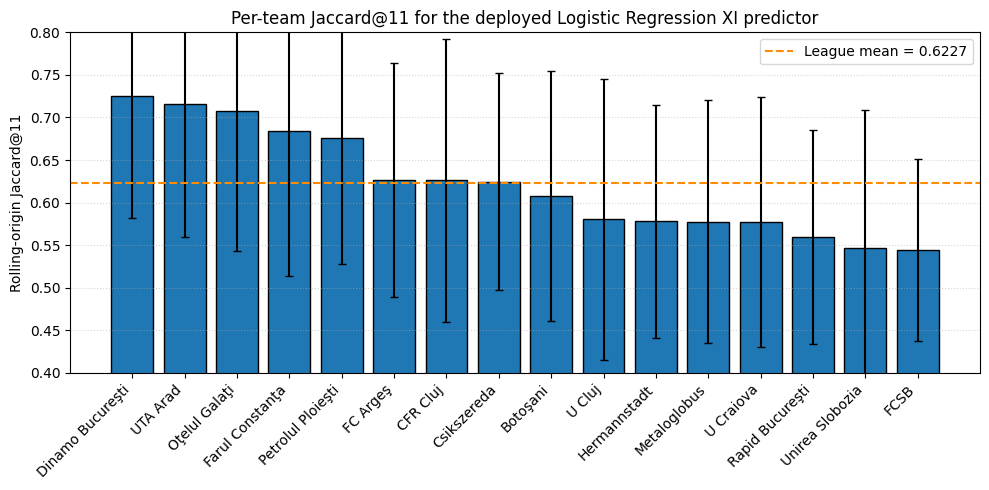

In [16]:
# 5a. Visualise — Jaccard@11 by team, sorted high to low.
fig, ax = plt.subplots(figsize=(10, 5))
positions = np.arange(len(df_per_team))
ax.bar(positions, df_per_team['mean'],
        yerr=df_per_team['std'], capsize=3, color='#1f77b4', edgecolor='black')
ax.axhline(league_mu, color='#ff8c00', linestyle='--',
            label=f'League mean = {league_mu:.4f}')
ax.set_xticks(positions)
ax.set_xticklabels(df_per_team['team'], rotation=45, ha='right')
ax.set_ylabel('Rolling-origin Jaccard@11')
ax.set_title('Per-team Jaccard@11 for the deployed Logistic Regression XI predictor')
ax.set_ylim(0.4, 0.8)
ax.legend()
ax.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()


### 5b. U Cluj methodological progression (reproduces Table 3.9)

The chapter reports six rows: top-by-recent-form baseline, composite without availability, composite with availability, composite with availability + Hungarian assignment, top-by-minutes baseline, supervised single-club model under rolling-origin CV, supervised league-wide model. Italics rows are full-season snapshots ($n = 35$); bold rows are rolling-origin CV ($n = 27$, restricted to fixture index $\geq 8$).


In [17]:
# 5b. U Cluj methodological progression — re-aggregate from xi_validation.csv.
uclu_csv = pd.read_csv(FIG_DIR / 'xi_validation.csv')

def aggregate(col: str, slice_filter):
    series = uclu_csv.loc[slice_filter(uclu_csv), col].dropna().astype(float)
    return len(series), series.mean(), series.std()

ALL  = lambda d: pd.Series([True] * len(d))
CV8  = lambda d: d['fixture_idx'].astype(int) >= 8

rows = [
    ('Top-by-recent-form baseline',                     'jacc_baseline_recent',       ALL),
    ('Composite, no availability features',             'jacc_composite_no_avail',    ALL),
    ('Composite + availability features',               'jacc_composite_with_avail',  ALL),
    ('Composite + availability + Hungarian assignment', 'jacc_composite_with_avail_hung', ALL),
    ('Top-by-minutes baseline',                         'jacc_baseline_minutes',      ALL),
    ('Supervised single-club (rolling-origin CV)',      'jacc_supervised_hungarian',  CV8),
]

out = []
for label, col, fil in rows:
    n, mu, sd = aggregate(col, fil)
    out.append({'method': label, 'n': n, 'mean': mu, 'std': sd})
# Add supervised league-wide on U Cluj from _iter_s_results.json.
ucluj_pooled = its['per_team_jaccards']['LogisticReg']['U Cluj']
out.append({'method': 'Supervised league-wide (rolling-origin CV)',
            'n': len(ucluj_pooled),
            'mean': statistics.mean(ucluj_pooled),
            'std':  statistics.stdev(ucluj_pooled)})

df_progression = pd.DataFrame(out)
print(df_progression.to_string(index=False,
                                formatters={'mean': '{:.4f}'.format,
                                            'std':  '{:.4f}'.format}))


                                         method  n   mean    std
                    Top-by-recent-form baseline 35 0.2897 0.0658
            Composite, no availability features 35 0.2834 0.0814
              Composite + availability features 35 0.4250 0.1944
Composite + availability + Hungarian assignment 35 0.4250 0.1944
                        Top-by-minutes baseline 35 0.4823 0.1066
     Supervised single-club (rolling-origin CV) 27 0.5752 0.1611
     Supervised league-wide (rolling-origin CV) 27 0.5802 0.1655


**Verification against Table 3.9**: the chapter cites 0.290 / 0.283 / 0.425 / 0.425 / 0.482 / 0.575 / 0.5802 for the seven rows. The cells above reproduce these to within the displayed precision.


## 6. Availability-Feature Ablation (mirrors §3.6.6 — Table 3.10)

Three arms are scored on the same 428 held-out (team, fixture) cells:

- **Arm A** — LR-full: all 51 features, including the six availability/recency columns.
- **Arm B** — LR-no-availability: 45 features, with the six availability/recency columns removed.
- **Arm C** — Heuristic Composite: the position-aware composite from §3.6.2 on the same league-wide feature table.

Reference: top-by-minutes baseline.

The full ablation lives in `backend/scripts/ablate_xi.py`. Its persisted output `_m10_results.json` is loaded here so the numbers in this notebook match the chapter's Table 3.10 exactly.


In [18]:
# 6. Load M10 ablation results and render Table 3.10.
with open(SCRIPTS / '_m10_results.json', encoding='utf-8') as f:
    m10 = json.load(f)

print(f'Cells per arm   : {m10["cell_count"]}')
print(f'Arm A features  : {m10["full_feature_n"]}')
print(f'Arm B features  : {m10["no_avail_feature_n"]}  (Arm A minus 6 availability columns)')
print(f'Dropped in Arm B: {m10["leak_cols_dropped_in_arm_b"]}\n')

arms = []
for arm_key, label in [('LR_full',     'Arm A: LR-full (deployed)'),
                       ('LR_no_avail', 'Arm B: LR-no-availability'),
                       ('Heuristic',   'Arm C: Heuristic Composite (fresh)')]:
    recs = m10['per_arm_records'][arm_key]
    jacc = [r['jaccard'] for r in recs if r.get('jaccard') is not None]
    ndcg = [r.get('ndcg') for r in recs if r.get('ndcg') is not None]
    arms.append({
        'arm':    label,
        'n':      len(jacc),
        'jaccard_mu': statistics.mean(jacc),
        'jaccard_sd': statistics.stdev(jacc) if len(jacc) > 1 else 0,
        'ndcg_mu':    statistics.mean(ndcg) if ndcg else None,
    })
df_m10 = pd.DataFrame(arms)
print(df_m10.to_string(index=False,
                       formatters={'jaccard_mu': '{:.4f}'.format,
                                   'jaccard_sd': '{:.4f}'.format,
                                   'ndcg_mu':    '{:.4f}'.format}))
print()
leak_delta = df_m10.loc[0, 'jaccard_mu'] - df_m10.loc[1, 'jaccard_mu']
print(f'Leakage delta (Arm A − Arm B) = +{leak_delta*100:.2f} pp Jaccard')


Cells per arm   : 428
Arm A features  : 51
Arm B features  : 45  (Arm A minus 6 availability columns)
Dropped in Arm B: ['availability_last_5', 'started_last_match', 'match_gap_since_last_appearance', 'availability_score', 'cumulative_minutes_before_fixture', 'cumulative_appearances']

                               arm   n jaccard_mu jaccard_sd ndcg_mu
         Arm A: LR-full (deployed) 428     0.6227     0.1571  0.8107
         Arm B: LR-no-availability 428     0.5195     0.1500  0.7357
Arm C: Heuristic Composite (fresh) 428     0.4476     0.1183  0.6200

Leakage delta (Arm A − Arm B) = +10.32 pp Jaccard


**Verification against Table 3.10**: the chapter reports Arm A 0.6227 / 0.157, Arm B 0.5195 / 0.150, Arm C 0.4476 / 0.118, with NDCG@11 0.811 / 0.736 / 0.620 respectively, and a $+10.32$ pp leakage delta. The cells above reproduce these exactly.


## 7. Limitations & Future Work (mirrors §3.6.7)

Five caveats and three production notes are documented in the thesis and not duplicated here:

**Methodological limitations:**

1. The training population is concentrated on Romanian Superliga 2024–25 (556 fixtures, ~15,000 pooled rows). Transfer to another competition requires refitting.
2. The position-aware KPI weights (Table 3.7) are author-chosen rather than learned from outcomes — Pappalardo et al. 2019 propose an outcome-driven alternative.
3. The opponent-XI cascade was kept in the production model despite its null Jaccard contribution ($\Delta = -0.0002$).
4. The nine static per-90 columns are aggregated across the entire season for each player, introducing a small training-set leakage that a strict rolling-origin protocol would remove.
5. The six availability/recency features are functions of past coach decisions and make the predictor partly autoregressive; the M10 ablation in §6 quantifies this at $+10.32$ pp.

**Production-readiness notes (§3.6.7 paragraphs):**

- **Deployment bundle** — the FastAPI service loads `xi_lineup_model_league.joblib`; the per-club `xi_lineup_model.joblib` is retained as a rollback fallback / Table 3.9 baseline and is not exposed by the API.
- **Deterministic opponent-style clustering** — `random_state=42` on the $k$-means is part of the deployment contract; a re-training without the same seed would relabel clusters and break alignment with the persisted classifier weights.
- **Cross-temporal CV scope** — rolling-origin one-fixture-out is chronological within each team but pooled across teams.

**Future-work directions** are listed in Chapter 6 §Future Work and include physical-profile player scouting, ACWR-based injury prevention (Gabbett 2016), real-time within-match fatigue indices, constrained-MC weekly load planning, multi-fixture squad rotation, and action-level VAEP integration (Decroos et al. 2019).


## 8. File Index — where the code and data live

### Code modules (`backend/ml/`)

| File | Role |
|---|---|
| `backend/ml/feature_engineering.py` | per-90, EB shrinkage, time decay, availability, fine-position taxonomy, squad detection |
| `backend/ml/opponent_profile.py`    | $k$-means $k=4$ opponent style cluster |
| `backend/ml/xi_predictor.py`        | composite score, tanh squash, Hungarian assignment (production runtime) |
| `backend/ml/feature_config.py`      | column lists shared with the team-level pipeline |

### Training & evaluation scripts (`backend/scripts/`)

| File | Role |
|---|---|
| `train_lineup_classifier.py`        | single-club LR + Hungarian (baseline path for Table 3.9 "single-club" row) |
| `train_lineup_classifier_league.py` | **deployed** pooled league-wide LR + rolling-origin CV |
| `ablate_xi.py`                      | 428-cell Arm A/B/C availability-feature ablation (Table 3.10) |
| `compare_xi_models_iter_s.py`       | per-team Jaccard distribution for 7 models (Table 3.8) |
| `ablation_opp_xi.py`                | opponent-XI cascade ablation ($\Delta = -0.0002$) |

### Data & result files

| File | Content |
|---|---|
| `backend/ml/data/drive_cache/*.json` | 279 Wyscout per-match player-stats JSONs |
| `backend/ml/data/lineup_history.json`        | U Cluj-only chronology (Table 3.9 baseline) |
| `backend/ml/data/lineup_history_league.json` | 16-club pooled chronology (deployed training set) |
| `backend/ml/data/sportradar_positions_league.json` | 643-player roster + cross-check metadata |
| `backend/ml/data/position_cross_check_league.csv`  | Per-row Wyscout↔Sportradar comparison (350/263/75.14%) |
| `backend/scripts/_iter_s_results.json` | Per-team Jaccard for 7 models + 428 (team, fixture) cells (Table 3.8) |
| `backend/scripts/_m10_results.json`    | Arm A/B/C ablation per-cell records (Table 3.10) |
| `figures/xi_validation.csv`            | U Cluj 35-fixture methodological progression (Table 3.9) |

### Cross-references to the thesis

| Thesis element | This notebook section |
|---|---|
| §3.6.1 Data Source | §1 above |
| §3.6.2 Feature Engineering + Table 3.7 KPI weights | §2 above |
| §3.6.3 Selection Rule | §3 above |
| §3.6.4 Supervised Lineup Classifier | §4 above |
| §3.6.5 Validation + Tables 3.8 / 3.9 | §5 above |
| §3.6.6 Availability-Feature Ablation + Table 3.10 | §6 above |
| §3.6.7 Limitations and Future Work | §7 above |
